# Exploratory Data Analysis — North Atlantic Right Whale SDM
## WhaleGuard ML Pipeline: Data Validation & Literature Cross-Reference

This notebook performs an exhaustive Exploratory Data Analysis (EDA) on the engineered dataset produced by the WhaleGuard ETL pipeline. The objective is to **empirically validate** that our data aligns with the current marine biology literature before training an XGBoost classifier.

### 1 — Data Loading & The "Missingness" Justification

Oceanographic satellite data is inherently incomplete. Cloud cover masks optical sensors (Chlorophyll-a), coastal interference corrupts microwave retrievals (Salinity), and temporal misalignment between satellite overpasses and sighting dates introduces systematic gaps.

**Ji et al. (2024)** demonstrated that tree-based ensemble models — specifically XGBoost and Random Forest — achieve the highest predictive accuracy for NARW presence *precisely because* of their native **Sparsity-Aware Split Finding** algorithm. Unlike neural networks or logistic regression, XGBoost does not require imputation; it learns an optimal default direction at each split node for missing values, preserving the statistical integrity of the non-missing data.

> **Key Implication:** We do *not* impute missing values. We document them here and rely on XGBoost's architectural strength to handle them natively.

Dataset: 64,901 rows × 14 columns
Date range: 2002-02-06 → 2018-01-27

<class 'pandas.DataFrame'>
RangeIndex: 64901 entries, 0 to 64900
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              64901 non-null  datetime64[us]
 1   Lat               64901 non-null  float64       
 2   Lon               64901 non-null  float64       
 3   Presence          64901 non-null  int64         
 4   SST               64689 non-null  float64       
 5   Chlorophyll       64417 non-null  float64       
 6   Salinity          62054 non-null  float64       
 7   Bathymetry        64901 non-null  float64       
 8   SST_Gradient      63860 non-null  float64       
 9   Is_Thermal_Front  64901 non-null  bool          
 10  Month             64901 non-null  int64         
 11  Bathy_Slope       64901 non-null  float64       
 12  Dist_to_Shore_km  64901 non-null  float64       
 13  Dist_to_Shelf_km

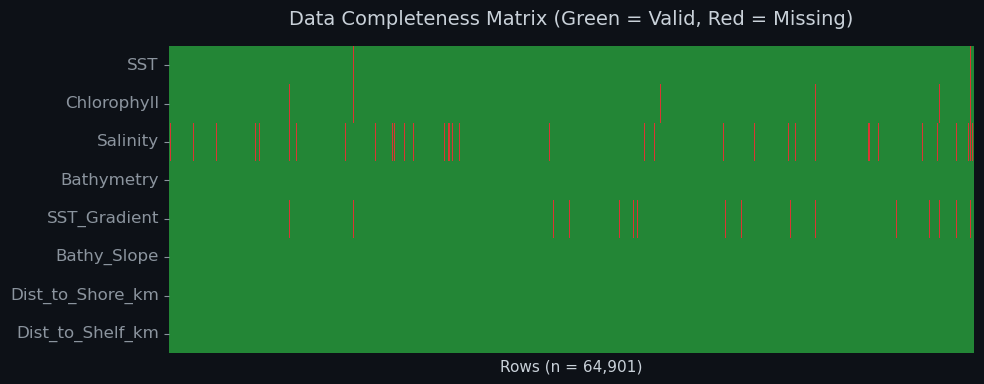


✓ Saved: images\missingness_heatmap.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Style Configuration ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
})

PALETTE = {'presence': '#58a6ff', 'absence': '#f778ba'}
IMG_DIR = Path('images')
IMG_DIR.mkdir(exist_ok=True)

# ── Load Dataset ────────────────────────────────────────────────────
df = pd.read_csv('data/processed/ML_Whale_Dataset_Final.csv', parse_dates=['Date'])
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}\n")
df.info()

# ── Missingness Table ───────────────────────────────────────────────
env_cols = ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Bathy_Slope', 'Dist_to_Shore_km', 'Dist_to_Shelf_km']
print("\n" + "=" * 60)
print("  MISSINGNESS REPORT (Ji et al., 2024 — Sparsity-Aware)")
print("=" * 60)
for col in env_cols:
    valid = df[col].notna().sum()
    total = len(df)
    pct = 100 * valid / total
    bar = '█' * int(pct // 2) + '░' * (50 - int(pct // 2))
    print(f"  {col:15s} {bar} {pct:5.1f}%  ({total - valid:,} NaN)")

# ── Missingness Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
missing_matrix = df[env_cols].isna().T
sns.heatmap(missing_matrix, cbar=False, cmap=['#238636', '#da3633'],
            yticklabels=env_cols, xticklabels=False, ax=ax)
ax.set_title('Data Completeness Matrix (Green = Valid, Red = Missing)', fontsize=14, pad=15)
ax.set_xlabel(f'Rows (n = {len(df):,})', fontsize=11)
fig.tight_layout()
fig.savefig(IMG_DIR / 'missingness_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: {IMG_DIR / 'missingness_heatmap.png'}")

### 2 — Observer Bias Elimination & Geographic Spatial Verification (Gowan & Ortega-Ortiz, 2014)

Visual sighting data suffers from severe **spatial observer bias**: whales are only recorded where survey vessels patrol. A model trained exclusively on presence data will learn *where boats look*, not *where whales live*.

Following **Gowan & Ortega-Ortiz (2014)**, our pipeline mitigates this through:
1. **1:4 Pseudo-Absence Ratio** — For every confirmed sighting, 4 synthetic "background" points are generated, preventing class imbalance artifacts.
2. **Temporal Matching** — Background points share the *exact same date* as the sighting, ensuring the model evaluates the specific oceanographic conditions of that day.
3. **Spatial Buffering** — Points are scattered within a **300 km radius** but *outside* a **15 km exclusion zone**, preventing false negatives near real sightings.
4. **Ocean-Only Validation** — All synthetic points are validated against a land mask (`global-land-mask`) to ensure none fall on land.

The geographic scatter plot below must confirm: (a) presence and absence points overlap broadly in the Northwest Atlantic, (b) absence points do *not* cluster on land, and (c) the spatial extent covers known NARW habitats (Cape Cod Bay, Great South Channel, Bay of Fundy, Gulf of St. Lawrence).

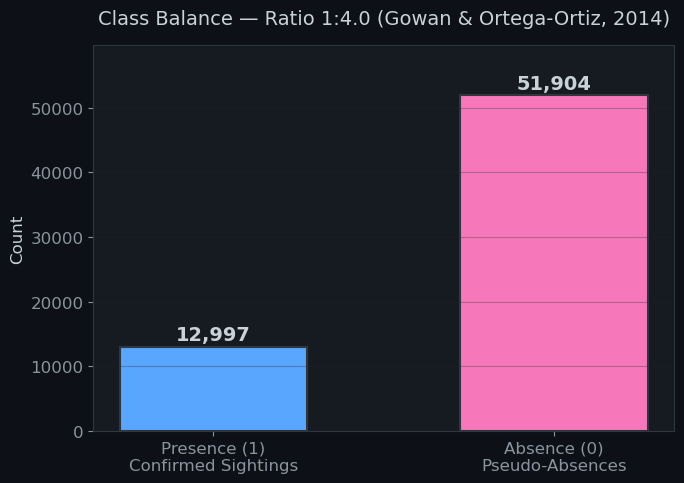

✓ Saved: images\class_balance.png


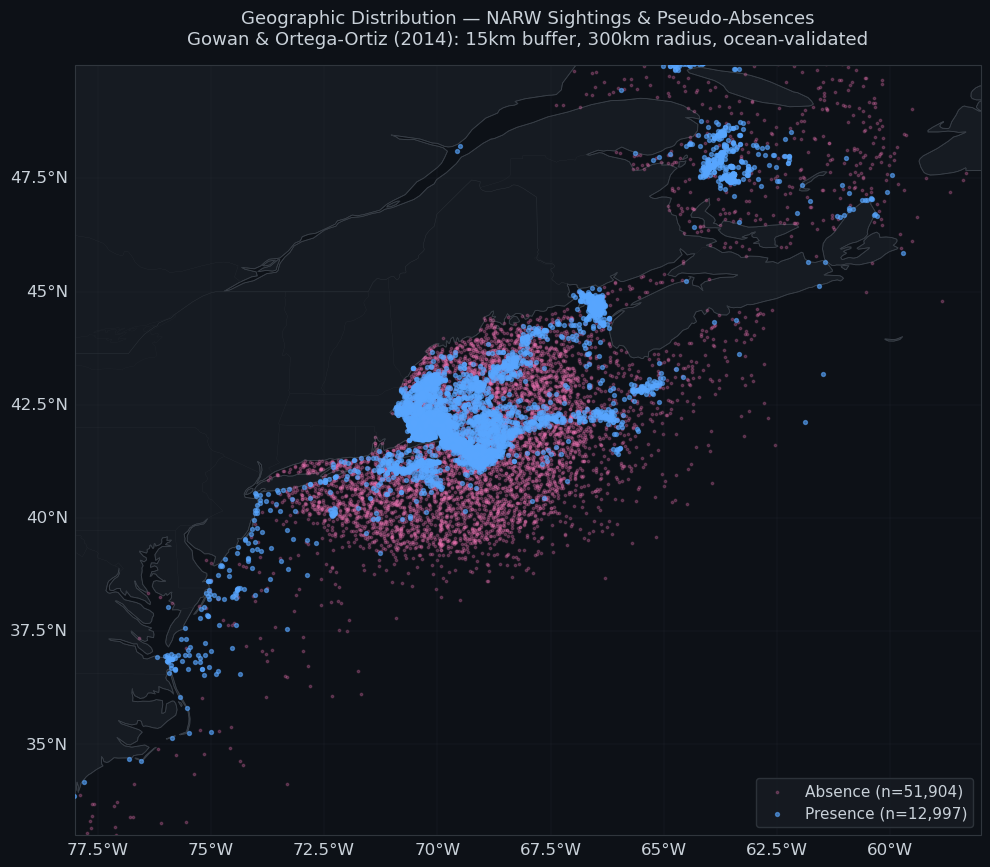

✓ Saved: images\geographic_distribution.png


In [2]:
# ── Class Balance ──
n_pres = (df['Presence'] == 1).sum()
n_abs  = (df['Presence'] == 0).sum()
ratio  = n_abs / n_pres

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Presence (1)\nConfirmed Sightings', 'Absence (0)\nPseudo-Absences'],
              [n_pres, n_abs],
              color=[PALETTE['presence'], PALETTE['absence']],
              edgecolor='#30363d', linewidth=1.5, width=0.55)
for bar, val in zip(bars, [n_pres, n_abs]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{val:,}', ha='center', va='bottom', fontsize=14, fontweight='bold', color='#c9d1d9')
ax.set_title(f'Class Balance — Ratio 1:{ratio:.1f} (Gowan & Ortega-Ortiz, 2014)', fontsize=14, pad=15)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, n_abs * 1.15)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(IMG_DIR / 'class_balance.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'class_balance.png'}")

# ── Geographic Scatter (Cartopy) ──
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df_abs  = df[df['Presence'] == 0].sample(n=min(8000, n_abs), random_state=42)
df_pres = df[df['Presence'] == 1]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-78, -58, 33, 50], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='#161b22', edgecolor='#30363d', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='#0d1117')
ax.add_feature(cfeature.COASTLINE, edgecolor='#484f58', linewidth=0.6)
ax.add_feature(cfeature.BORDERS, edgecolor='#30363d', linewidth=0.3)
ax.add_feature(cfeature.STATES, edgecolor='#21262d', linewidth=0.2)

ax.scatter(df_abs['Lon'], df_abs['Lat'], c=PALETTE['absence'],
           s=3, alpha=0.25, transform=ccrs.PlateCarree(), label=f'Absence (n={n_abs:,})', zorder=2)
ax.scatter(df_pres['Lon'], df_pres['Lat'], c=PALETTE['presence'],
           s=8, alpha=0.6, transform=ccrs.PlateCarree(), label=f'Presence (n={n_pres:,})', zorder=3)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='#30363d', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.legend(loc='lower right', fontsize=11, framealpha=0.9,
          facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.set_title('Geographic Distribution — NARW Sightings & Pseudo-Absences\n'
             'Gowan & Ortega-Ortiz (2014): 15km buffer, 300km radius, ocean-validated',
             fontsize=13, pad=15, color='#c9d1d9')

fig.savefig(IMG_DIR / 'geographic_distribution.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"✓ Saved: {IMG_DIR / 'geographic_distribution.png'}")


### 3 — The "Goldilocks Zone": Bivariate Habitat Envelope (Tao et al., 2025)

**Tao et al. (2025)** identified the critical bivariate habitat envelope for NARW aggregation. Right whales do not forage randomly — they concentrate at the **intersection** of two conditions:

1. **Bathymetric Preference (50–200m depth):** NARWs target the continental shelf where upwelling concentrates *Calanus finmarchicus* copepods in dense subsurface layers.
2. **Thermal Front Activity (SST Gradient > 0.035°C/km):** Convergent thermal boundaries physically trap copepod patches, creating the energy-dense foraging zones whales depend on.

The KDE contour plot below should show a clear density peak for `Presence=1` points within the rectangle defined by these two thresholds — the "Goldilocks Zone" where both conditions are simultaneously satisfied.

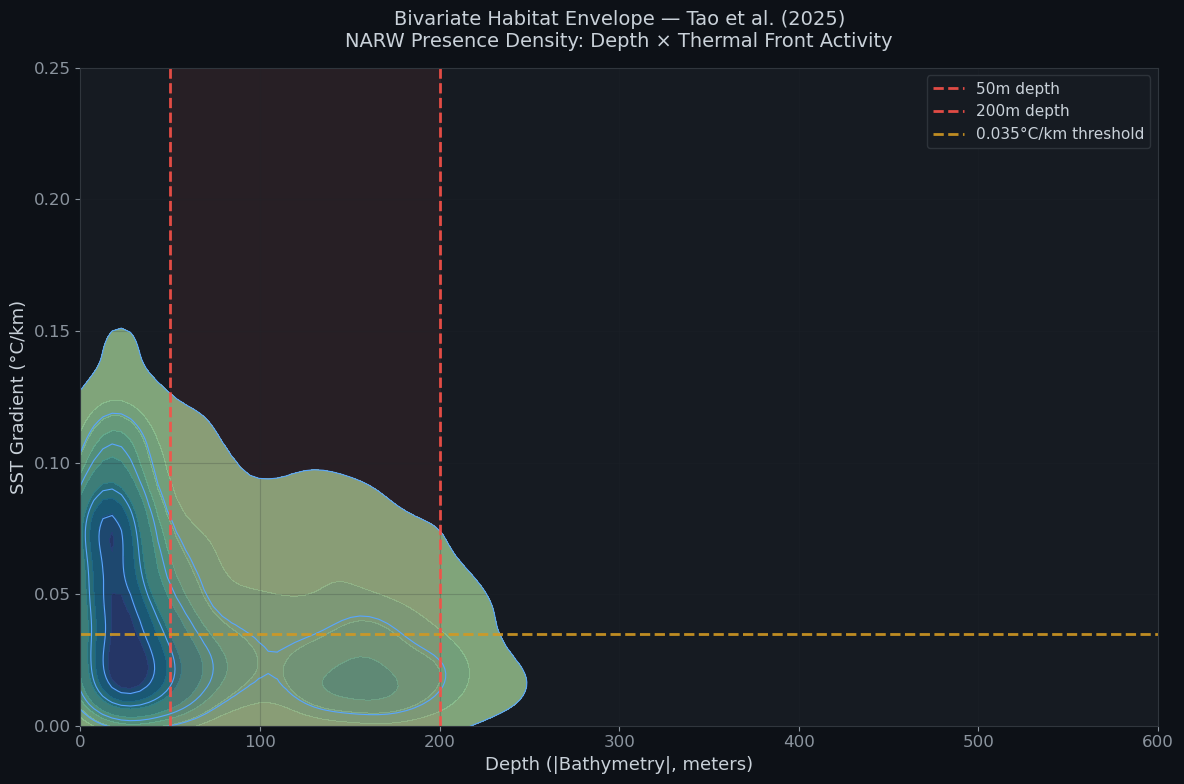

✓ Saved: images\tao_contour.png


In [3]:
# ── Tao et al. 2D KDE Contour ───────────────────────────────────────
pres = df[(df['Presence'] == 1) & df['SST_Gradient'].notna() & df['Bathymetry'].notna()].copy()
pres['Depth'] = pres['Bathymetry'].abs()  # Convert to positive depth

fig, ax = plt.subplots(figsize=(12, 8))

# KDE contour for presence points
x = pres['Depth'].values
y = pres['SST_Gradient'].values

# Filter to reasonable ranges for visualization
mask = (x < 1000) & (y < 0.3)
x, y = x[mask], y[mask]

try:
    sns.kdeplot(x=x, y=y, levels=10, fill=True, cmap='crest', alpha=0.8, ax=ax)
    sns.kdeplot(x=x, y=y, levels=6, fill=False, colors='#58a6ff', linewidths=0.8, ax=ax)
except:
    ax.scatter(x, y, c=PALETTE['presence'], s=2, alpha=0.3)

# Threshold lines (Tao et al., 2025)
ax.axvline(50, color='#f85149', linestyle='--', linewidth=2, alpha=0.9, label='50m depth')
ax.axvline(200, color='#f85149', linestyle='--', linewidth=2, alpha=0.9, label='200m depth')
ax.axhline(0.035, color='#d29922', linestyle='--', linewidth=2, alpha=0.9, label='0.035°C/km threshold')

# Shade the Goldilocks Zone
ax.axvspan(50, 200, alpha=0.08, color='#f85149')
ax.axhspan(0.035, ax.get_ylim()[1], xmin=50/ax.get_xlim()[1], xmax=200/ax.get_xlim()[1],
           alpha=0.0)  # Reference only

ax.set_xlabel('Depth (|Bathymetry|, meters)', fontsize=13)
ax.set_ylabel('SST Gradient (°C/km)', fontsize=13)
ax.set_title('Bivariate Habitat Envelope — Tao et al. (2025)\n'
             'NARW Presence Density: Depth × Thermal Front Activity',
             fontsize=14, pad=15)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9,
          facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.set_xlim(0, 600)
ax.set_ylim(0, 0.25)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(IMG_DIR / 'tao_contour.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'tao_contour.png'}")

### 3.1 — Bivariate Habitat Envelope: Depth vs. Bathymetric Slope



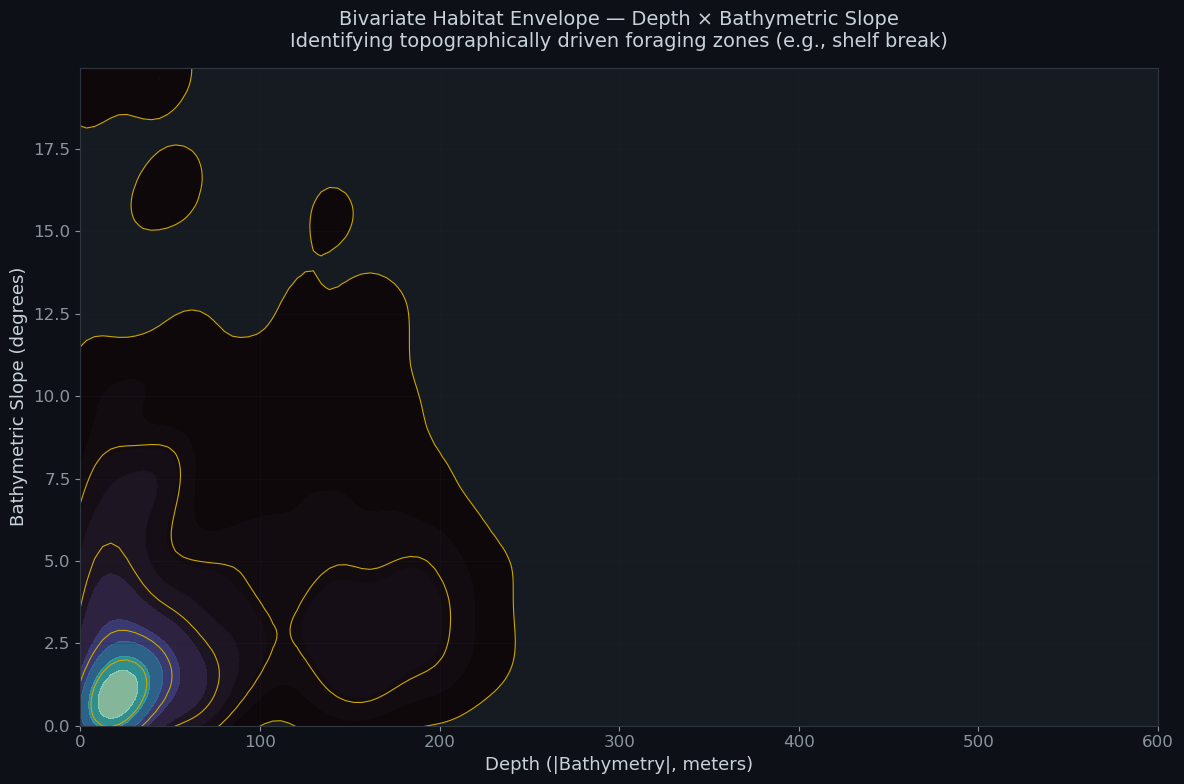

✓ Saved: images\depth_slope_contour.png


In [4]:
# ── Bivariate KDE Contour: Depth vs. Bathymetric Slope ──
pres = df[(df['Presence'] == 1) & df['Bathy_Slope'].notna() & df['Bathymetry'].notna()].copy()
pres['Depth'] = pres['Bathymetry'].abs()

fig, ax = plt.subplots(figsize=(12, 8))

x = pres['Depth'].values
y = pres['Bathy_Slope'].values

# Filter for visualization
mask = (x < 1000) & (y < 20)
x, y = x[mask], y[mask]

try:
    sns.kdeplot(x=x, y=y, levels=10, fill=True, cmap='mako', alpha=0.8, ax=ax)
    sns.kdeplot(x=x, y=y, levels=6, fill=False, colors='#cca700', linewidths=0.8, ax=ax)
except:
    ax.scatter(x, y, c=PALETTE['presence'], s=2, alpha=0.3)

ax.set_xlabel('Depth (|Bathymetry|, meters)', fontsize=13)
ax.set_ylabel('Bathymetric Slope (degrees)', fontsize=13)
ax.set_title('Bivariate Habitat Envelope — Depth × Bathymetric Slope\n'
             'Identifying topographically driven foraging zones (e.g., shelf break)',
             fontsize=14, pad=15)
ax.set_xlim(0, 600)
if len(y) > 0:
    ax.set_ylim(0, max(y.max(), 5))
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(IMG_DIR / 'depth_slope_contour.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"\u2713 Saved: {IMG_DIR / 'depth_slope_contour.png'}")


### 4 — Univariate Feature Distributions: Mosnier et al. (2025) Validation

**Mosnier et al. (2025)** validated that four pelagic variables govern NARW distribution in the Gulf of St. Lawrence:

- **SST:** NARWs prefer cooler waters (8–15°C) associated with *Calanus finmarchicus* thermal tolerance.
- **Chlorophyll-a:** Higher concentrations indicate phytoplankton blooms — the base of the copepod food web.
- **Salinity:** Intermediate salinity (~31–33 PSU) marks the mixing zones where nutrient-rich deep water meets surface layers.
- **Bathymetry:** Strong preference for the 50–200m continental shelf.

Each plot below compares the distribution of `Presence=1` (blue) vs `Presence=0` (pink). A clear **separation** between the two curves for a given feature indicates that feature has strong discriminative power for the ML model.

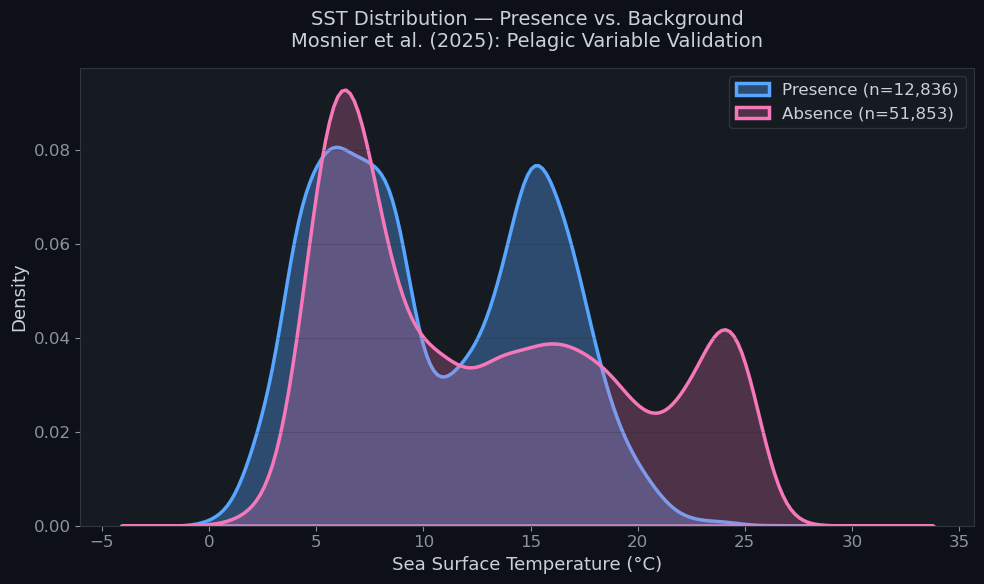

✓ Saved: images\kde_sst.png


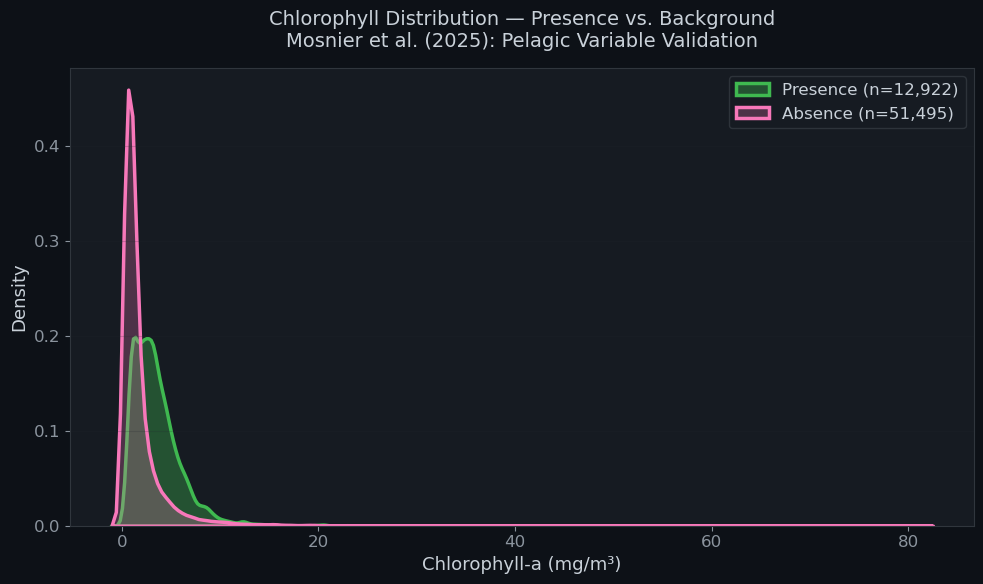

✓ Saved: images\kde_chlorophyll.png


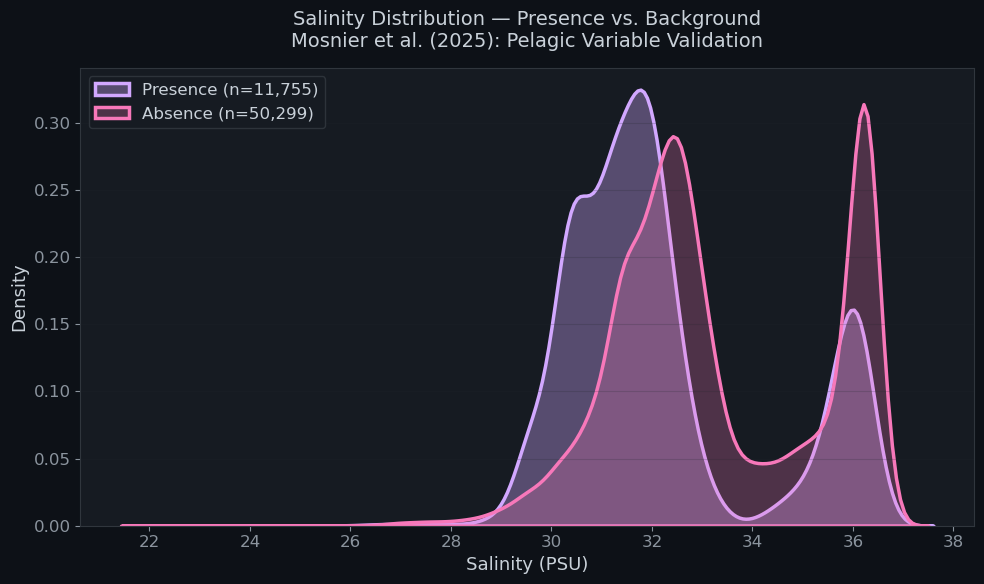

✓ Saved: images\kde_salinity.png


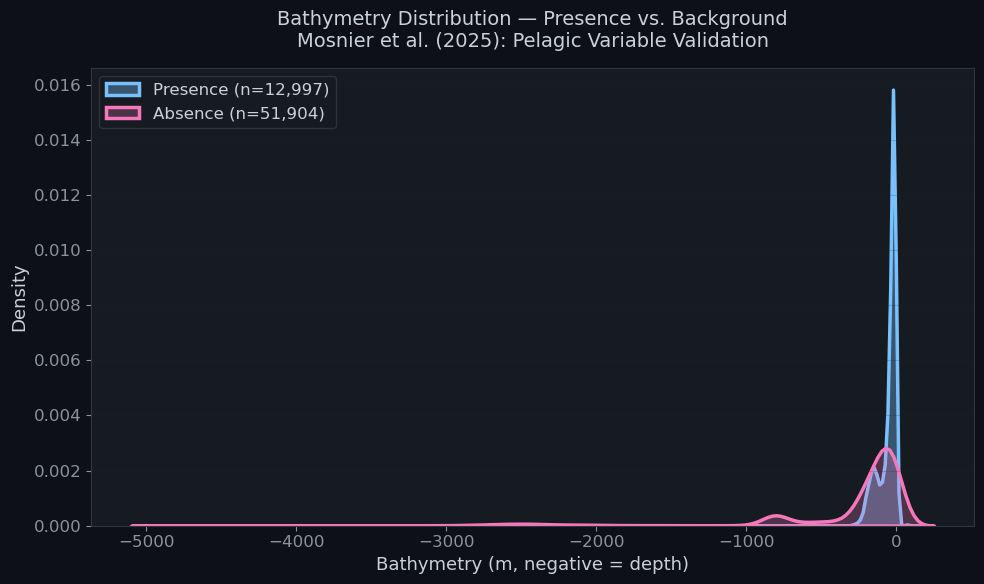

✓ Saved: images\kde_bathymetry.png


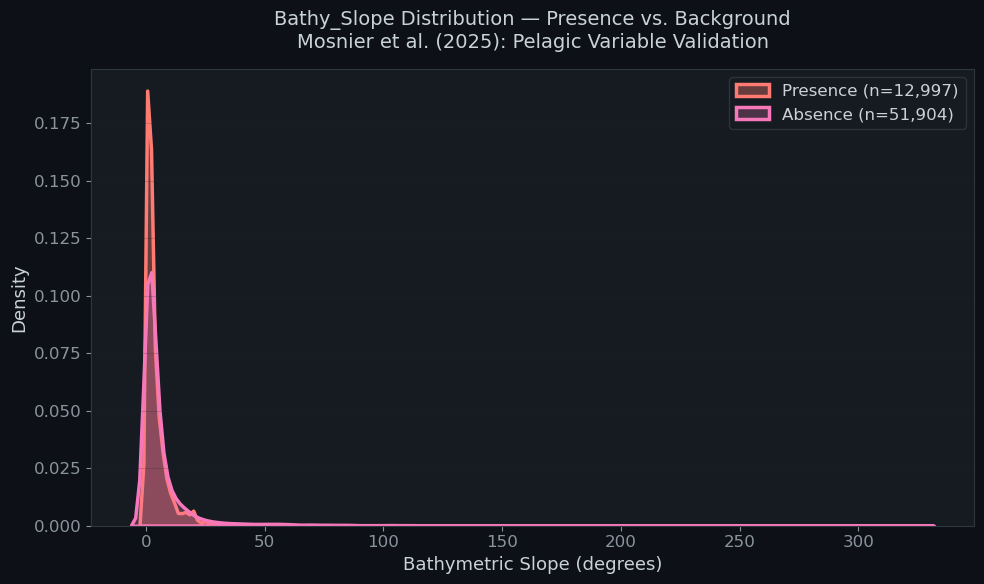

✓ Saved: images\kde_bathy_slope.png


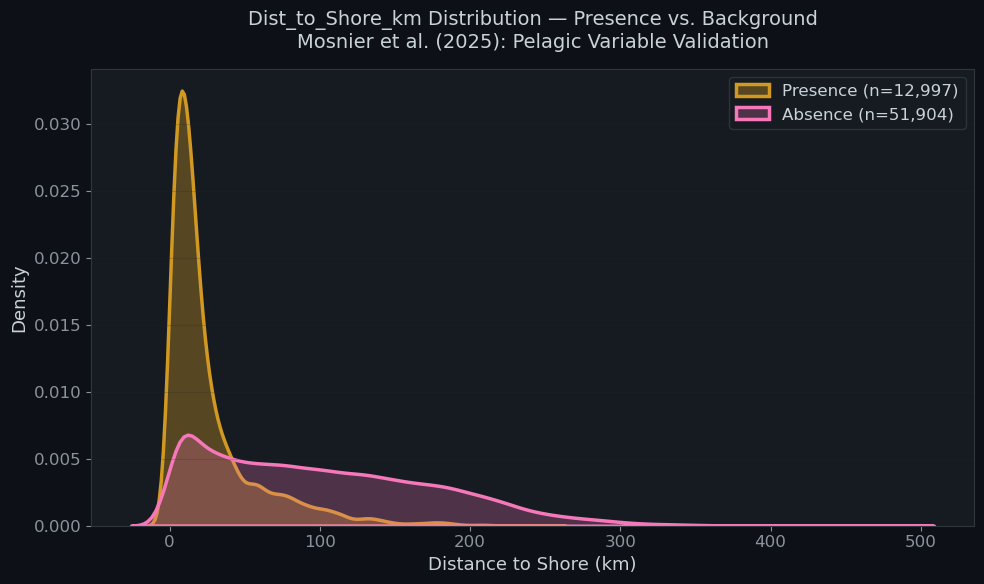

✓ Saved: images\kde_dist_to_shore_km.png


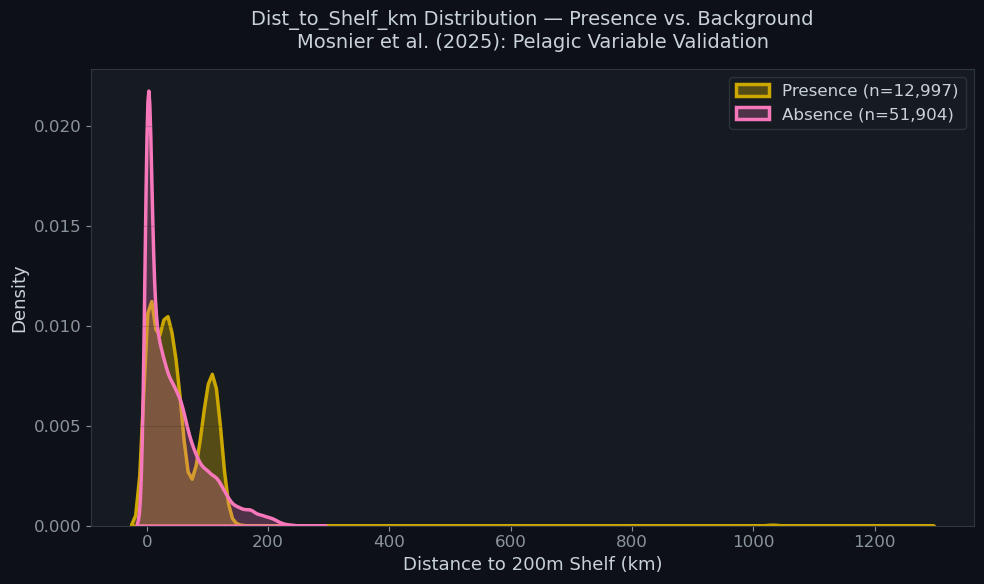

✓ Saved: images\kde_dist_to_shelf_km.png


In [5]:
# ── Individual KDE Plots (Mosnier et al., 2025) ─────────────────────
features = {
    'SST': {'xlabel': 'Sea Surface Temperature (°C)', 'color_p': '#58a6ff', 'color_a': '#f778ba'},
    'Chlorophyll': {'xlabel': 'Chlorophyll-a (mg/m³)', 'color_p': '#3fb950', 'color_a': '#f778ba'},
    'Salinity': {'xlabel': 'Salinity (PSU)', 'color_p': '#d2a8ff', 'color_a': '#f778ba'},
    'Bathymetry': {'xlabel': 'Bathymetry (m, negative = depth)', 'color_p': '#79c0ff', 'color_a': '#f778ba'},

    'Bathy_Slope': {'xlabel': 'Bathymetric Slope (degrees)', 'color_p': '#ff7b72', 'color_a': '#f778ba'},
    'Dist_to_Shore_km': {'xlabel': 'Distance to Shore (km)', 'color_p': '#d29922', 'color_a': '#f778ba'},
    'Dist_to_Shelf_km': {'xlabel': 'Distance to 200m Shelf (km)', 'color_p': '#cca700', 'color_a': '#f778ba'},}

pres_df = df[df['Presence'] == 1]
abs_df  = df[df['Presence'] == 0]

for feat, cfg in features.items():
    fig, ax = plt.subplots(figsize=(10, 6))

    pres_vals = pres_df[feat].dropna()
    abs_vals  = abs_df[feat].dropna()

    if len(pres_vals) > 0:
        sns.kdeplot(pres_vals, ax=ax, color=cfg['color_p'], fill=True, alpha=0.35,
                    linewidth=2.5, label=f'Presence (n={len(pres_vals):,})')
    if len(abs_vals) > 0:
        sns.kdeplot(abs_vals, ax=ax, color=cfg['color_a'], fill=True, alpha=0.25,
                    linewidth=2.5, label=f'Absence (n={len(abs_vals):,})')

    ax.set_xlabel(cfg['xlabel'], fontsize=13)
    ax.set_ylabel('Density', fontsize=13)
    ax.set_title(f'{feat} Distribution — Presence vs. Background\n'
                 f'Mosnier et al. (2025): Pelagic Variable Validation',
                 fontsize=14, pad=15)
    ax.legend(fontsize=12, framealpha=0.9,
              facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
    ax.grid(axis='y', alpha=0.2)
    fig.tight_layout()

    fname = IMG_DIR / f'kde_{feat.lower()}.png'
    fig.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")

### 5 — Empirical Threshold Validation

Visual KDE plots provide intuition, but **quantitative validation** is essential. Here we calculate the exact empirical percentages to determine what fraction of confirmed NARW sightings fall within the habitat thresholds identified by the literature:

1. **Bathymetric envelope:** 50–200m depth (Tao et al., 2025)
2. **Thermal front activity:** SST_Gradient > 0.035°C/km (Tao et al., 2025)
3. **Combined "Goldilocks Zone":** Both conditions simultaneously satisfied

In [6]:
# ── Threshold Statistics ─────────────────────────────────────────────
pres = df[df['Presence'] == 1].copy()
abs_ = df[df['Presence'] == 0].copy()

pres['Depth'] = pres['Bathymetry'].abs()
abs_['Depth'] = abs_['Bathymetry'].abs()

print("=" * 65)
print("  EMPIRICAL THRESHOLD VALIDATION — Tao et al. (2025)")
print("=" * 65)

# Bathymetry 50-200m
pres_bathy = pres['Depth'].dropna()
in_range_p = ((pres_bathy >= 50) & (pres_bathy <= 200)).sum()
pct_p = 100 * in_range_p / len(pres_bathy)

abs_bathy = abs_['Depth'].dropna()
in_range_a = ((abs_bathy >= 50) & (abs_bathy <= 200)).sum()
pct_a = 100 * in_range_a / len(abs_bathy)

print(f"\n  1. Bathymetric Envelope (50–200m depth):")
print(f"     Presence:  {in_range_p:>6,}/{len(pres_bathy):,}  =  {pct_p:.1f}%")
print(f"     Absence:   {in_range_a:>6,}/{len(abs_bathy):,}  =  {pct_a:.1f}%")
print(f"     → Enrichment factor: {pct_p/pct_a:.2f}x" if pct_a > 0 else "")

# Thermal fronts
pres_front = pres['Is_Thermal_Front'].sum()
pct_front_p = 100 * pres_front / len(pres)
abs_front = abs_['Is_Thermal_Front'].sum()
pct_front_a = 100 * abs_front / len(abs_)

print(f"\n  2. Active Thermal Fronts (SST_Gradient > 0.035°C/km):")
print(f"     Presence:  {pres_front:>6,}/{len(pres):,}  =  {pct_front_p:.1f}%")
print(f"     Absence:   {abs_front:>6,}/{len(abs_):,}  =  {pct_front_a:.1f}%")
print(f"     → Enrichment factor: {pct_front_p/pct_front_a:.2f}x" if pct_front_a > 0 else "")

# Combined Goldilocks
pres_gold = pres[(pres['Depth'] >= 50) & (pres['Depth'] <= 200) & (pres['Is_Thermal_Front'] == True)]
pct_gold_p = 100 * len(pres_gold) / len(pres)
abs_gold = abs_[(abs_['Depth'] >= 50) & (abs_['Depth'] <= 200) & (abs_['Is_Thermal_Front'] == True)]
pct_gold_a = 100 * len(abs_gold) / len(abs_)

print(f"\n  3. Combined 'Goldilocks Zone' (50–200m AND thermal front):")
print(f"     Presence:  {len(pres_gold):>6,}/{len(pres):,}  =  {pct_gold_p:.1f}%")
print(f"     Absence:   {len(abs_gold):>6,}/{len(abs_):,}  =  {pct_gold_a:.1f}%")
print(f"     → Enrichment factor: {pct_gold_p/pct_gold_a:.2f}x" if pct_gold_a > 0 else "")

print("\n" + "=" * 65)
print("  INTERPRETATION")
print("=" * 65)
print("  If enrichment factors > 1.0, the feature discriminates well.")
print("  Values > 2.0 indicate strong ecological signal — exactly what")
print("  XGBoost will exploit for high-accuracy classification.")
print("=" * 65)

  EMPIRICAL THRESHOLD VALIDATION — Tao et al. (2025)

  1. Bathymetric Envelope (50–200m depth):
     Presence:   4,039/12,997  =  31.1%
     Absence:   20,458/51,904  =  39.4%
     → Enrichment factor: 0.79x

  2. Active Thermal Fronts (SST_Gradient > 0.035°C/km):
     Presence:   7,021/12,997  =  54.0%
     Absence:   25,617/51,904  =  49.4%
     → Enrichment factor: 1.09x

  3. Combined 'Goldilocks Zone' (50–200m AND thermal front):
     Presence:   1,828/12,997  =  14.1%
     Absence:    8,979/51,904  =  17.3%
     → Enrichment factor: 0.81x

  INTERPRETATION
  If enrichment factors > 1.0, the feature discriminates well.
  Values > 2.0 indicate strong ecological signal — exactly what
  XGBoost will exploit for high-accuracy classification.


### 6 — Temporal Feature Engineering: Month as a Predictor

NARW habitat use is **profoundly seasonal**. Right whales migrate between calving grounds in the warm Southeast U.S. (Dec–Mar) and foraging grounds in the cold North Atlantic (Jun–Oct). Without a temporal feature, the model cannot distinguish "5°C water in January near Cape Cod" (calving context) from "5°C water in July off Nova Scotia" (foraging context) — two scenarios with identical SST but entirely different ecological meaning.

Every major NARW SDM study includes temporal context. We extract `Month` from the `Date` column as an integer feature (1–12). XGBoost will learn month-dependent split rules (e.g., "if Month > 5 AND SST < 12°C → high whale probability").

In [7]:
# ── Add Month Feature ────────────────────────────────────────────────
df['Month'] = df['Date'].dt.month
print(f"Added 'Month' column (range: {df['Month'].min()} – {df['Month'].max()})")
print(f"Updated columns: {', '.join(df.columns)}")
print(f"\nMonth value counts:")
print(df['Month'].value_counts().sort_index().to_string())

# Save updated dataset with Month column
df.to_csv('data/processed/ML_Whale_Dataset_Final.csv', index=False)
print(f"\n✓ Updated CSV saved with Month column")

Added 'Month' column (range: 1 – 12)
Updated columns: Date, Lat, Lon, Presence, SST, Chlorophyll, Salinity, Bathymetry, SST_Gradient, Is_Thermal_Front, Month, Bathy_Slope, Dist_to_Shore_km, Dist_to_Shelf_km

Month value counts:
Month
1      7280
2      9365
3      8940
4     16450
5      6615
6      2560
7      3140
8      2970
9      1695
10     1130
11     1491
12     3265



✓ Updated CSV saved with Month column


### 7 — Seasonal Sighting Frequency & Migration Pattern

This histogram reveals the **temporal survey coverage** and the well-documented NARW **migration cycle**. We expect to see:
- A winter peak (Dec–Mar) corresponding to calving surveys off the Southeast U.S.
- A spring-summer peak (Apr–Sep) corresponding to foraging surveys in the Gulf of Maine, Bay of Fundy, and Gulf of St. Lawrence.

Any month with very few sightings indicates a **data gap** — the model will have less information about whale behavior in those conditions. This is critical context for interpreting model performance.

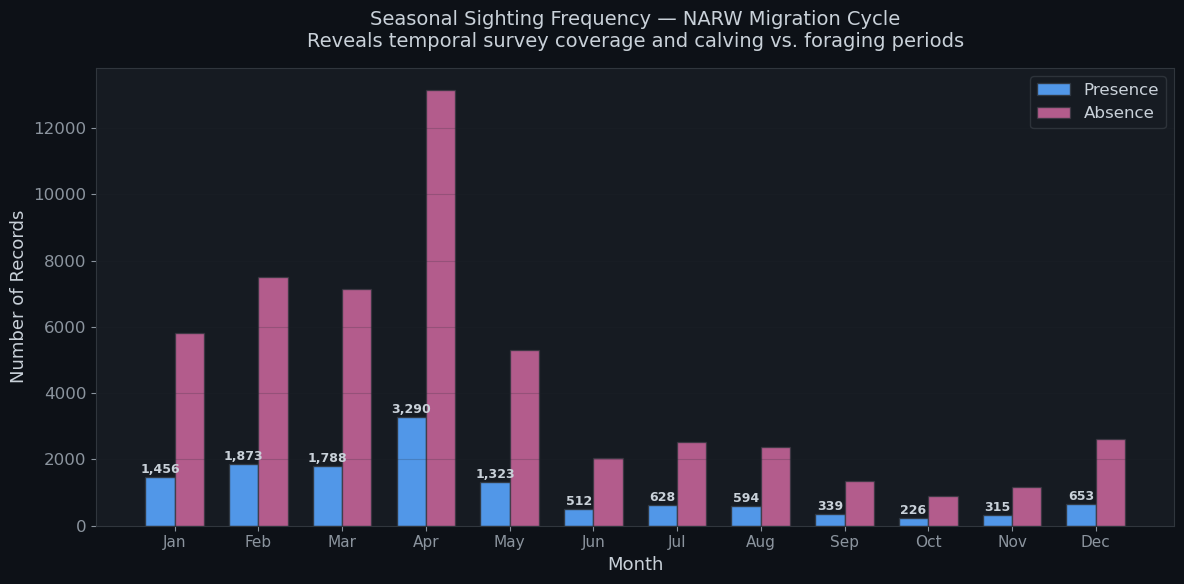

✓ Saved: images\seasonal_histogram.png

Peak sighting month: Apr (3,290 sightings)
Lowest sighting month: Oct (226 sightings)


In [8]:
# ── Seasonal Histogram ───────────────────────────────────────────────
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pres_months = df[df['Presence'] == 1]['Month'].value_counts().sort_index()
abs_months  = df[df['Presence'] == 0]['Month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(1, 13)
width = 0.35

bars1 = ax.bar(x - width/2, [pres_months.get(m, 0) for m in range(1, 13)],
               width, color=PALETTE['presence'], edgecolor='#30363d',
               linewidth=1, label='Presence', alpha=0.9)
bars2 = ax.bar(x + width/2, [abs_months.get(m, 0) for m in range(1, 13)],
               width, color=PALETTE['absence'], edgecolor='#30363d',
               linewidth=1, label='Absence', alpha=0.7)

ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Number of Records', fontsize=13)
ax.set_title('Seasonal Sighting Frequency — NARW Migration Cycle\n'
             'Reveals temporal survey coverage and calving vs. foraging periods',
             fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=11)
ax.legend(fontsize=12, framealpha=0.9,
          facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(axis='y', alpha=0.2)

# Add count labels on presence bars
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 30,
                f'{int(h):,}', ha='center', va='bottom', fontsize=9,
                color='#c9d1d9', fontweight='bold')

fig.tight_layout()
fig.savefig(IMG_DIR / 'seasonal_histogram.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'seasonal_histogram.png'}")

# Print peak months
peak = pres_months.idxmax()
print(f"\nPeak sighting month: {month_names[peak-1]} ({pres_months[peak]:,} sightings)")
print(f"Lowest sighting month: {month_names[pres_months.idxmin()-1]} ({pres_months.min():,} sightings)")

### 7.1 — Presence Rate by Year and Month


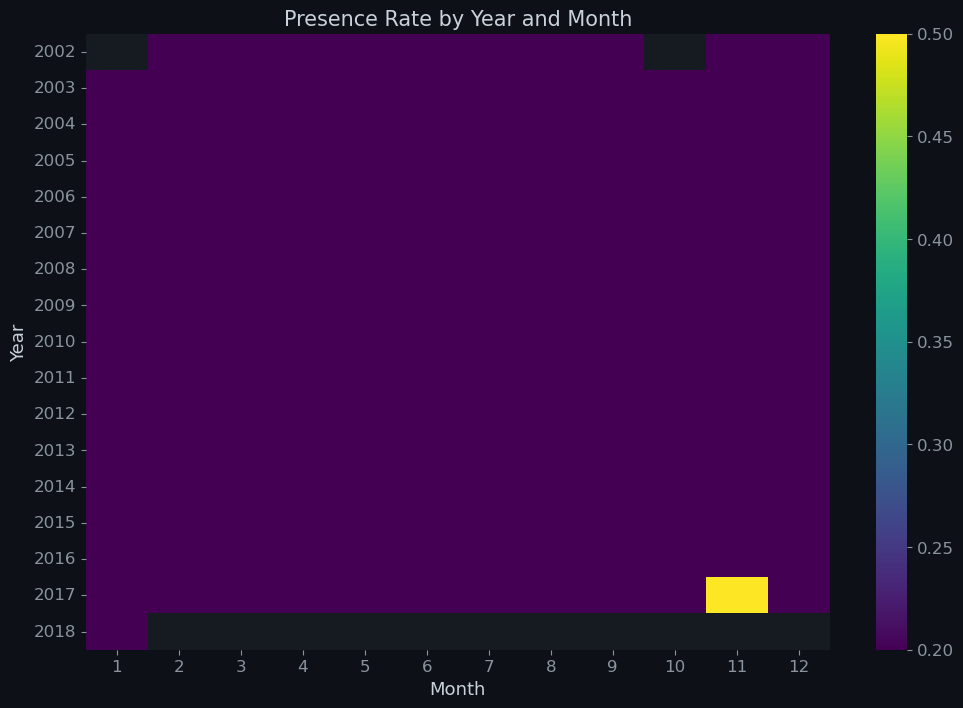

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Calculate presence rate (mean of Presence)
heatmap_data = df.groupby(['Year', 'Month'])['Presence'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=False)
plt.title('Presence Rate by Year and Month')
plt.ylabel('Year')
plt.xlabel('Month')
plt.show()

### 8 — Presence Rate vs. Environmental Variables

To understand how the probability of encountering a NARW changes with environmental conditions, we calculate the **presence rate** (proportion of `Presence=1`) across decile bins of each pelagic variable.



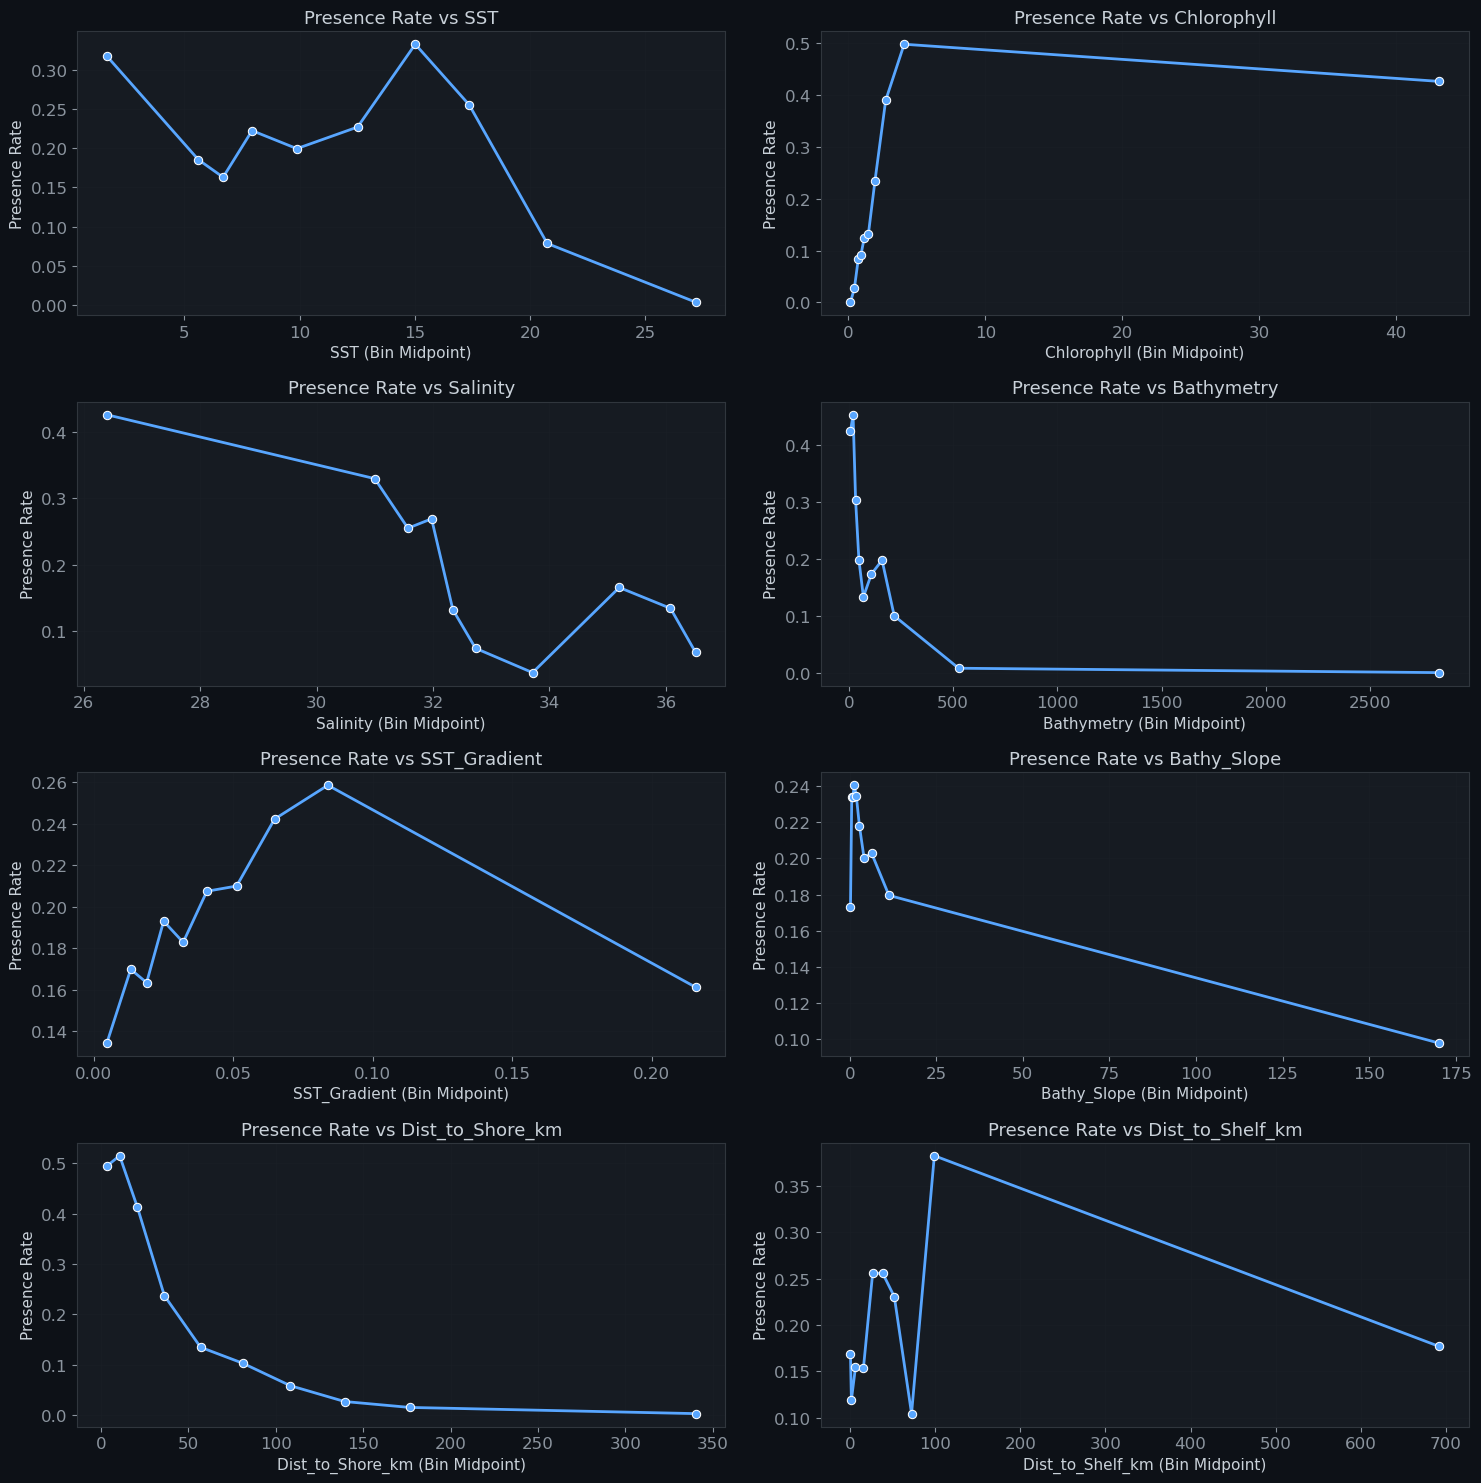

✓ Saved: images\presence_rate_vs_env.png


In [10]:
# ── Presence Rate vs. Environmental Variables ────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.flatten()

features_to_plot = ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Bathy_Slope', 'Dist_to_Shore_km' , 'Dist_to_Shelf_km']

for i, feat in enumerate(features_to_plot):
    df_plot = df.copy()
    if feat == 'Bathymetry':
        # Use absolute depth
        feat_col = 'Depth'
        df_plot[feat_col] = df_plot['Bathymetry'].abs()
    else:
        feat_col = feat
        
    # Create decile bins
    df_plot['bin'] = pd.qcut(df_plot[feat_col], q=10, duplicates='drop')
    
    # Calculate presence rate
    rate_df = df_plot.groupby('bin', observed=False)['Presence'].mean().reset_index()
    # Get the midpoint of each bin for plotting
    rate_df['bin_mid'] = rate_df['bin'].apply(lambda x: x.mid).astype(float)
    
    sns.lineplot(data=rate_df, x='bin_mid', y='Presence', ax=axes[i], marker='o', linewidth=2, color=PALETTE['presence'])
    axes[i].set_title(f'Presence Rate vs {feat}', fontsize=13)
    axes[i].set_ylabel('Presence Rate', fontsize=11)
    axes[i].set_xlabel(f'{feat} (Bin Midpoint)', fontsize=11)
    axes[i].grid(alpha=0.2)

# Hide the 6th empty subplot
# axes[5].set_visible(False) # Removed to show Bathy_Slope

fig.tight_layout()
fig.savefig(IMG_DIR / 'presence_rate_vs_env.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'presence_rate_vs_env.png'}")


### 9 — Month-Stratified Presence Rate Heatmaps

To capture the seasonal dynamics of habitat preferences, these heatmaps show the **presence rate** stratified by both **Month** (y-axis) and **Environmental Variable Bins** (x-axis).



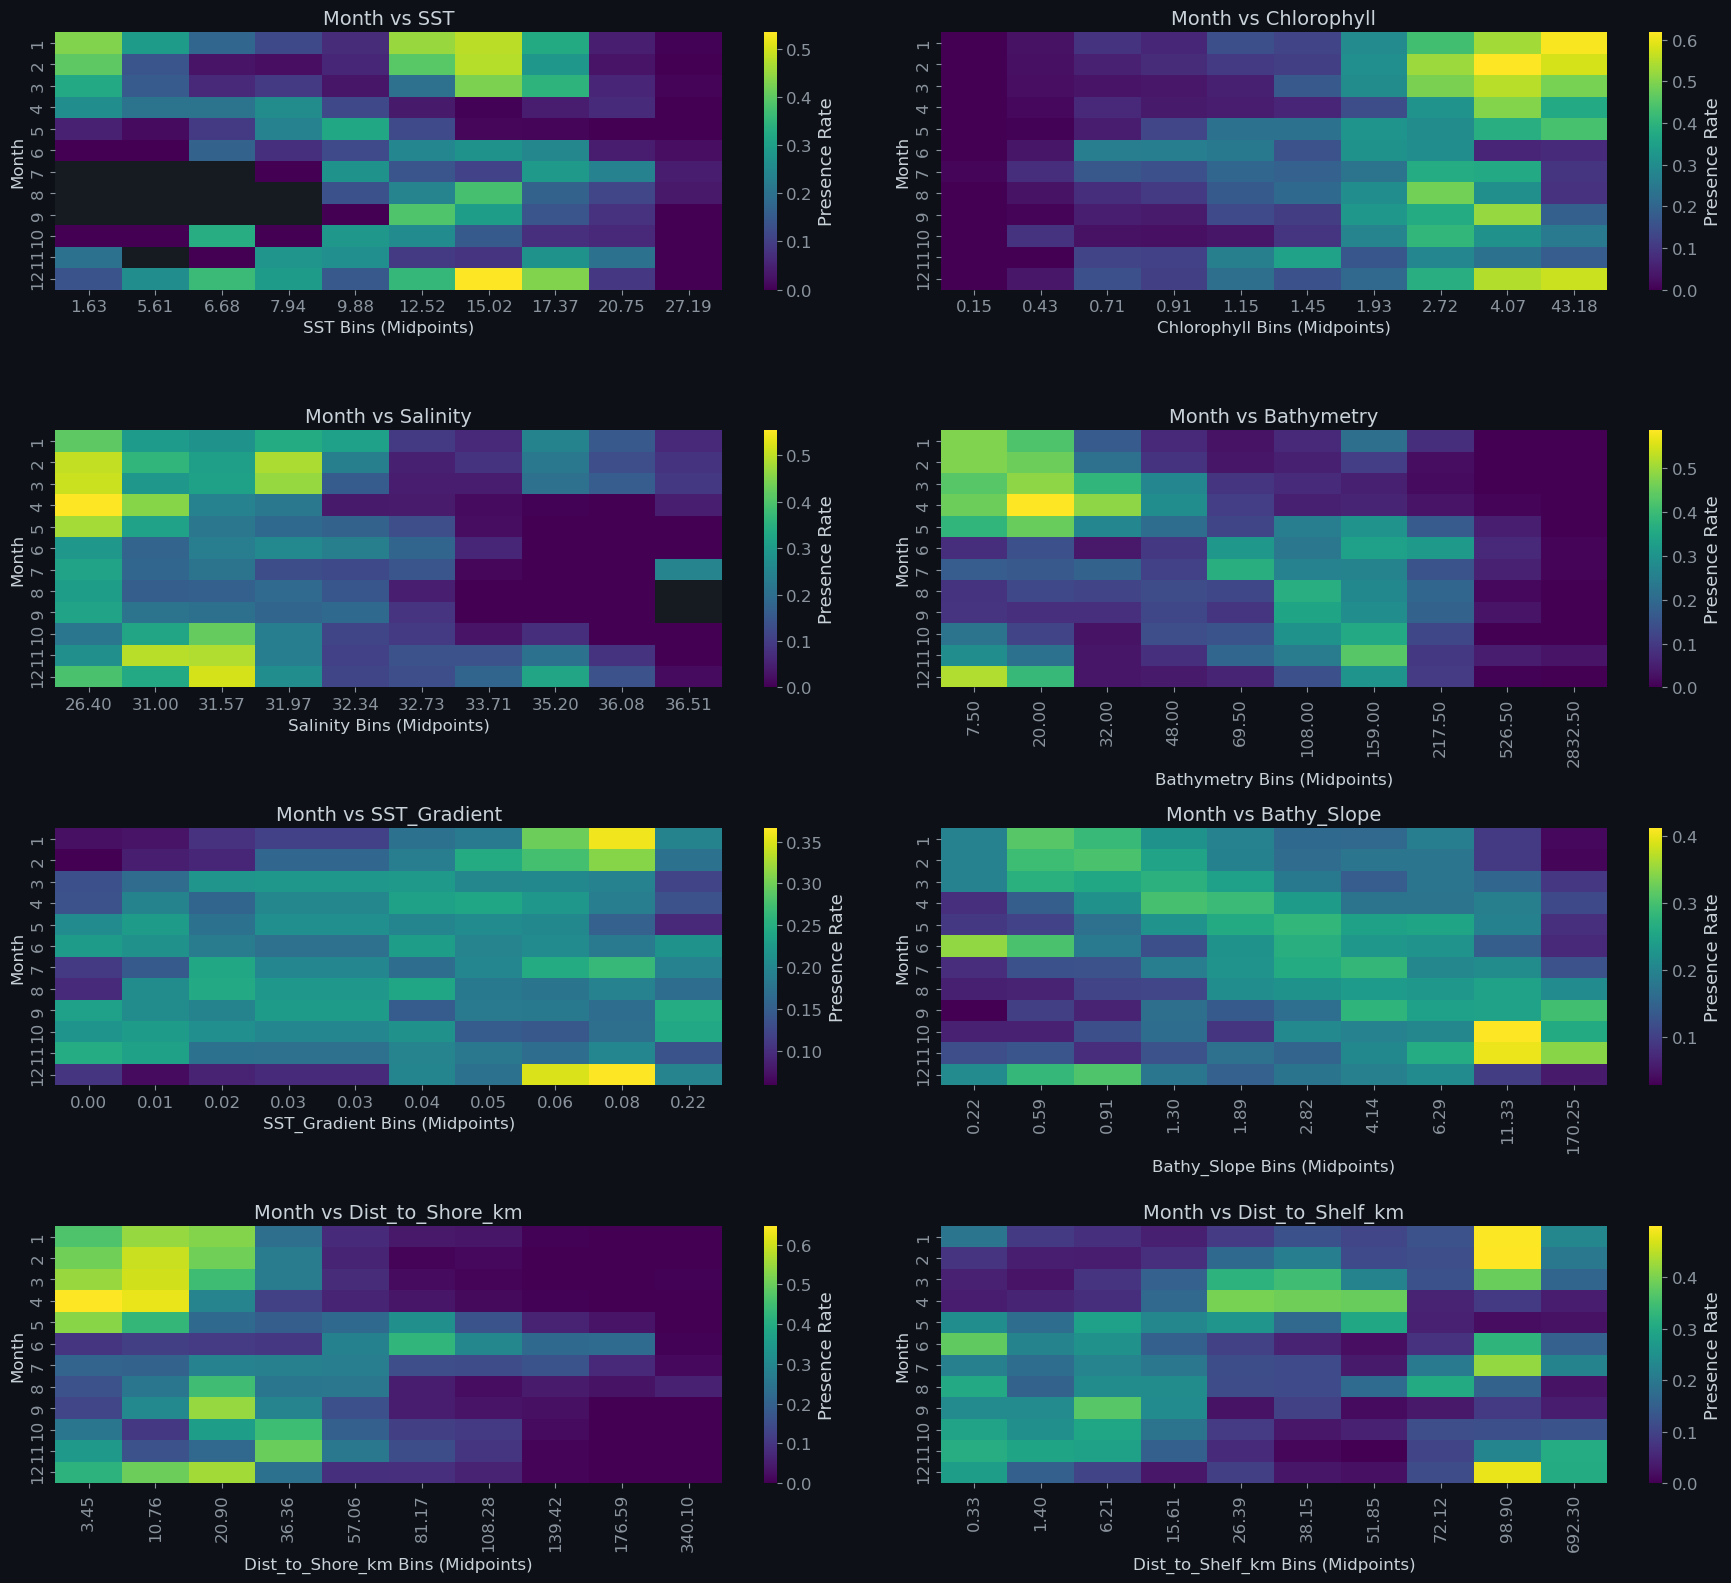

✓ Saved: images\month_stratified_presence_heatmaps.png


In [11]:
# ── Month-Stratified Presence Rate Heatmaps ─────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

features_to_plot = ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Bathy_Slope', 'Dist_to_Shore_km' , 'Dist_to_Shelf_km']

for i, feat in enumerate(features_to_plot):
    df_plot = df.copy()
    if feat == 'Bathymetry':
        feat_col = 'Depth'
        df_plot[feat_col] = df_plot['Bathymetry'].abs()
    else:
        feat_col = feat
        
    # Create decile bins for the feature
    df_plot['bin'] = pd.qcut(df_plot[feat_col], q=10, duplicates='drop')
    
    # Format bin labels to be readable strings (midpoints)
    df_plot['bin_label'] = df_plot['bin'].apply(lambda x: f"{x.mid:.2f}" if pd.notnull(x) else None)
    
    # Calculate presence rate grouped by Month and the feature bin
    heatmap_data = df_plot.groupby(['Month', 'bin_label'], observed=False)['Presence'].mean().unstack()
    
    # Sort columns by the actual interval midpoints to maintain numerical order
    bin_order = sorted(df_plot['bin'].dropna().unique(), key=lambda x: x.mid)
    col_order = [f"{b.mid:.2f}" for b in bin_order]
    heatmap_data = heatmap_data.reindex(columns=col_order)
    
    sns.heatmap(heatmap_data, cmap='viridis', ax=axes[i], annot=False, cbar_kws={'label': 'Presence Rate'})
    axes[i].set_title(f'Month vs {feat}', fontsize=14)
    axes[i].set_ylabel('Month', fontsize=12)
    axes[i].set_xlabel(f'{feat} Bins (Midpoints)', fontsize=12)

# Hide the 6th empty subplot
# axes[5].set_visible(False) # Removed to show Bathy_Slope

fig.tight_layout()
fig.savefig(IMG_DIR / 'month_stratified_presence_heatmaps.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'month_stratified_presence_heatmaps.png'}")


### 10 — Mann-Whitney U Tests: Statistical Validation of Feature Discrimination

Visual KDE overlap can be misleading. The **Mann-Whitney U test** (non-parametric) quantifies whether two distributions are statistically significantly different, without assuming normality. For each environmental feature, we test:

**H₀:** The distribution of Feature X is identical for Presence=1 and Presence=0.
**H₁:** The distributions differ.

A p-value < 0.05 means the distributions are significantly different — the feature carries discriminative information. The **effect size (rank-biserial correlation)** tells us *how different* they are:
- |r| < 0.1 → negligible
- |r| 0.1–0.3 → small
- |r| 0.3–0.5 → medium


In [12]:
# ── Mann-Whitney U Tests ─────────────────────────────────────────────
from scipy.stats import mannwhitneyu

test_features = ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Bathy_Slope', 'Dist_to_Shore_km', 'Dist_to_Shelf_km']

pres_df = df[df['Presence'] == 1]
abs_df  = df[df['Presence'] == 0]

print("=" * 75)
print("  MANN-WHITNEY U TESTS — Feature Discrimination Significance")
print("=" * 75)
print(f"  {'Feature':15s} {'U-statistic':>14s} {'p-value':>12s} {'Effect (r)':>12s} {'Strength':>12s}")
print("-" * 75)

results = []
for feat in test_features:
    p_vals = pres_df[feat].dropna().values
    a_vals = abs_df[feat].dropna().values

    if len(p_vals) < 10 or len(a_vals) < 10:
        print(f"  {feat:15s} — insufficient data —")
        continue

    u_stat, p_val = mannwhitneyu(p_vals, a_vals, alternative='two-sided')

    # Rank-biserial correlation (effect size)
    n1, n2 = len(p_vals), len(a_vals)
    r = 1 - (2 * u_stat) / (n1 * n2)

    if abs(r) >= 0.5:
        strength = "LARGE ⭐"
    elif abs(r) >= 0.3:
        strength = "MEDIUM"
    elif abs(r) >= 0.1:
        strength = "SMALL"
    else:
        strength = "negligible"

    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"

    print(f"  {feat:15s} {u_stat:>14,.0f} {p_val:>12.2e} {r:>+12.4f} {strength:>12s} {sig}")
    results.append({'feature': feat, 'r': abs(r), 'p': p_val})

print("-" * 75)
print("  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant")
print("  Effect size:  rank-biserial correlation (r)")
print("=" * 75)

# Rank features by effect size
results.sort(key=lambda x: x['r'], reverse=True)
print("\n  Feature Ranking by Discriminative Power:")
for i, r in enumerate(results):
    bar = '█' * int(r['r'] * 40)
    print(f"    {i+1}. {r['feature']:15s} |r| = {r['r']:.4f}  {bar}")

  MANN-WHITNEY U TESTS — Feature Discrimination Significance
  Feature            U-statistic      p-value   Effect (r)     Strength
---------------------------------------------------------------------------
  SST                273,352,662    3.83e-216      +0.1786        SMALL ***
  Chlorophyll        522,508,420     0.00e+00      -0.5705      LARGE ⭐ ***
  Salinity           184,165,302     0.00e+00      +0.3770       MEDIUM ***
  Bathymetry         504,680,056     0.00e+00      -0.4962       MEDIUM ***
  SST_Gradient       343,794,304     3.87e-49      -0.0854   negligible ***
  Bathy_Slope        309,807,546     5.66e-47      +0.0815   negligible ***
  Dist_to_Shore_km    116,033,721     0.00e+00      +0.6560      LARGE ⭐ ***
  Dist_to_Shelf_km    376,284,559     1.35e-92      -0.1156        SMALL ***
---------------------------------------------------------------------------
  Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant
  Effect size:  rank-biserial corr

### 11 — Kernel PCA: Non-Linear Feature Space Visualization

Individual feature comparisons (Sections 4, 8) show whether *single* variables discriminate presence from absence. But NARW habitat selection depends on **interactions** between variables — a whale needs the right depth *and* the right SST *and* active thermal fronts *simultaneously*.

**Kernel PCA** with an RBF (Gaussian) kernel projects the full multi-dimensional environmental feature space into 2D using a non-linear mapping. If presence and absence points separate into distinct clusters in this projection, it confirms that the features *collectively* carry strong discriminative signal — exactly what XGBoost will exploit.



Kernel PCA input: 61,109 rows (after dropping NaN)
Features: ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Month']
Subsampled to 8,000 points for Kernel PCA


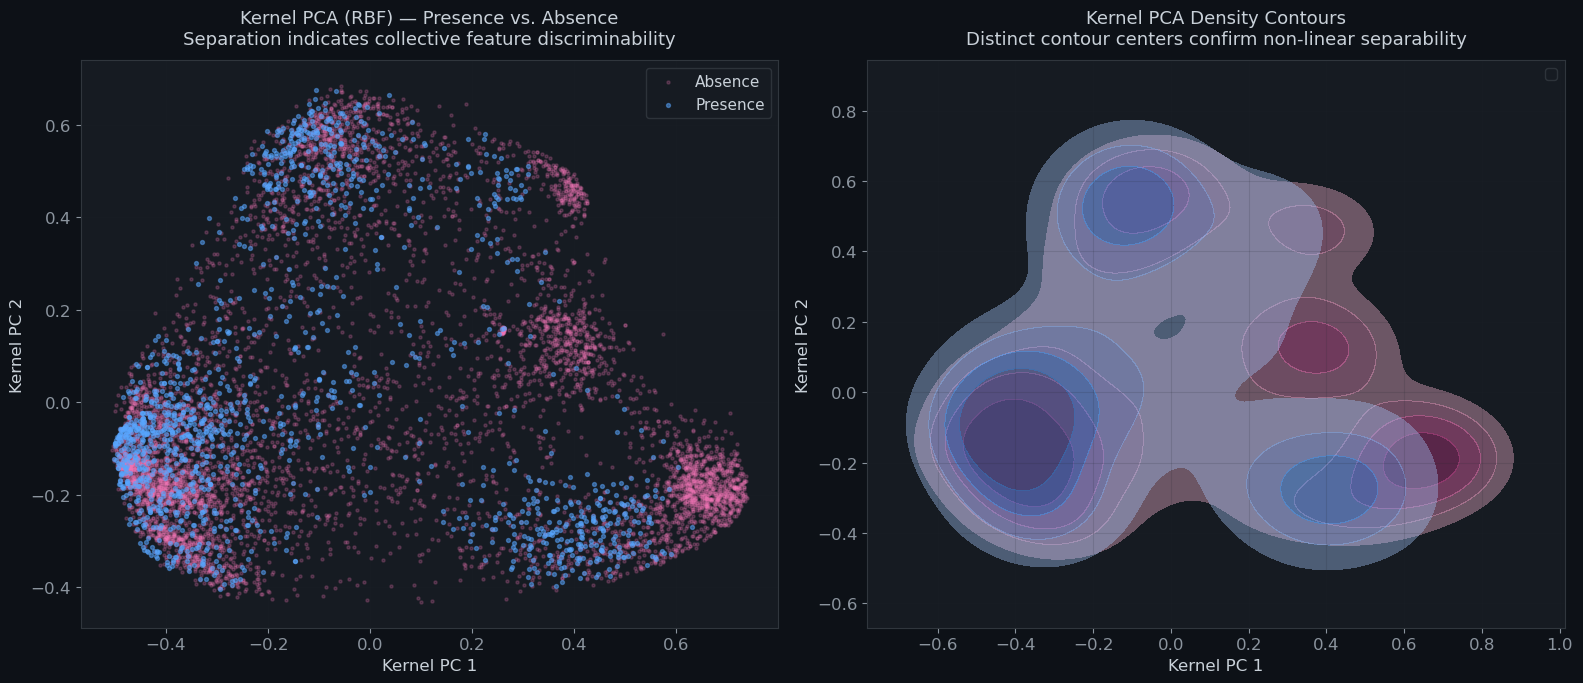

✓ Saved: images\kernel_pca.png

  KERNEL PCA SEPARABILITY SUMMARY
  Centroid distance:          0.1504
  Avg within-class spread:    0.1496
  Fisher-like ratio:          1.0051
  ✅ Strong separation — features collectively discriminate well.


In [13]:
# ── Kernel PCA: Non-Linear Feature Space Projection ───────────────────
from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler

# Select environmental features and drop rows with any NaN
kpca_features = ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Month']
df_kpca = df[kpca_features + ['Presence']].dropna().copy()

print(f"Kernel PCA input: {len(df_kpca):,} rows (after dropping NaN)")
print(f"Features: {kpca_features}")

# Standardize features (critical for RBF kernel)
scaler = StandardScaler()
X = scaler.fit_transform(df_kpca[kpca_features])
y = df_kpca['Presence'].values

# Subsample for performance (Kernel PCA scales O(n^2))
np.random.seed(42)
n_sample = min(8000, len(X))
idx = np.random.choice(len(X), n_sample, replace=False)
X_sub = X[idx]
y_sub = y[idx]
print(f"Subsampled to {n_sample:,} points for Kernel PCA")

# Fit Kernel PCA with RBF kernel
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, random_state=42)
X_kpca = kpca.fit_transform(X_sub)

# ── Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Scatter plot colored by class
abs_mask = y_sub == 0
pres_mask = y_sub == 1

axes[0].scatter(X_kpca[abs_mask, 0], X_kpca[abs_mask, 1],
                c=PALETTE['absence'], s=5, alpha=0.2, label='Absence', zorder=2)
axes[0].scatter(X_kpca[pres_mask, 0], X_kpca[pres_mask, 1],
                c=PALETTE['presence'], s=8, alpha=0.5, label='Presence', zorder=3)
axes[0].set_xlabel('Kernel PC 1', fontsize=12)
axes[0].set_ylabel('Kernel PC 2', fontsize=12)
axes[0].set_title('Kernel PCA (RBF) — Presence vs. Absence\n'
                  'Separation indicates collective feature discriminability',
                  fontsize=13, pad=12)
axes[0].legend(fontsize=11, framealpha=0.9,
               facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
axes[0].grid(alpha=0.15)

# Right: KDE contours for each class
try:
    sns.kdeplot(x=X_kpca[abs_mask, 0], y=X_kpca[abs_mask, 1],
                levels=5, fill=True, color=PALETTE['absence'], alpha=0.4,
                ax=axes[1], label='Absence')
    sns.kdeplot(x=X_kpca[pres_mask, 0], y=X_kpca[pres_mask, 1],
                levels=5, fill=True, color=PALETTE['presence'], alpha=0.4,
                ax=axes[1], label='Presence')
except Exception:
    axes[1].scatter(X_kpca[abs_mask, 0], X_kpca[abs_mask, 1],
                    c=PALETTE['absence'], s=3, alpha=0.2, label='Absence')
    axes[1].scatter(X_kpca[pres_mask, 0], X_kpca[pres_mask, 1],
                    c=PALETTE['presence'], s=5, alpha=0.4, label='Presence')

axes[1].set_xlabel('Kernel PC 1', fontsize=12)
axes[1].set_ylabel('Kernel PC 2', fontsize=12)
axes[1].set_title('Kernel PCA Density Contours\n'
                  'Distinct contour centers confirm non-linear separability',
                  fontsize=13, pad=12)
axes[1].legend(fontsize=11, framealpha=0.9,
               facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
axes[1].grid(alpha=0.15)

fig.tight_layout()
fig.savefig(IMG_DIR / 'kernel_pca.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'kernel_pca.png'}")

# ── Quantitative separability metric ─────────────────────────────────────
from scipy.spatial.distance import cdist

pres_center = X_kpca[pres_mask].mean(axis=0)
abs_center = X_kpca[abs_mask].mean(axis=0)
centroid_dist = np.linalg.norm(pres_center - abs_center)

pres_spread = np.std(cdist(X_kpca[pres_mask], [pres_center]))
abs_spread = np.std(cdist(X_kpca[abs_mask], [abs_center]))
avg_spread = (pres_spread + abs_spread) / 2

fisher_ratio = centroid_dist / avg_spread if avg_spread > 0 else 0

print(f"\n{'=' * 60}")
print(f"  KERNEL PCA SEPARABILITY SUMMARY")
print(f"{'=' * 60}")
print(f"  Centroid distance:          {centroid_dist:.4f}")
print(f"  Avg within-class spread:    {avg_spread:.4f}")
print(f"  Fisher-like ratio:          {fisher_ratio:.4f}")
print(f"{'=' * 60}")
if fisher_ratio > 1.0:
    print(f"  ✅ Strong separation — features collectively discriminate well.")
elif fisher_ratio > 0.5:
    print(f"  ⚠️  Moderate separation — some overlap, but signal exists.")
else:
    print(f"  ❌ Weak separation — features may not discriminate well.")
print(f"{'=' * 60}")


### 12 — Multicollinearity Check: Feature Independence

Before feeding features into a tree-based model, we must verify they are not excessively correlated. High multicollinearity (|r| > 0.85) between features can:
- Inflate feature importance scores
- Make SHAP explanations unreliable
- Reduce model generalizability



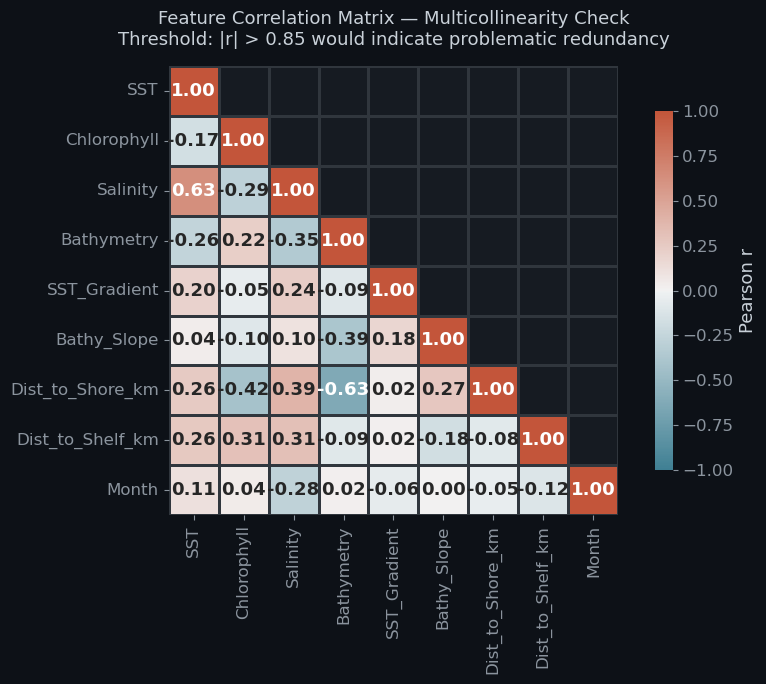

✓ Saved: images\correlation_heatmap.png

Correlation Summary (|r| > 0.5 flagged):
  SST             ↔ Salinity       :  r = +0.632 ⚠ MODERATE
  Chlorophyll     ↔ Dist_to_Shore_km:  r = -0.416
  Chlorophyll     ↔ Dist_to_Shelf_km:  r = +0.310
  Salinity        ↔ Bathymetry     :  r = -0.345
  Salinity        ↔ Dist_to_Shore_km:  r = +0.391
  Salinity        ↔ Dist_to_Shelf_km:  r = +0.313
  Bathymetry      ↔ Bathy_Slope    :  r = -0.386
  Bathymetry      ↔ Dist_to_Shore_km:  r = -0.630 ⚠ MODERATE

✅ EDA Complete. Dataset is validated and ready for XGBoost training.


In [14]:
# ── Correlation Heatmap ──────────────────────────────────────────────
corr_cols = ['SST', 'Chlorophyll', 'Salinity', 'Bathymetry', 'SST_Gradient', 'Bathy_Slope', 'Dist_to_Shore_km', 'Dist_to_Shelf_km', 'Month']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=1, linecolor='#30363d',
            square=True, ax=ax,
            annot_kws={'size': 13, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'})

ax.set_title('Feature Correlation Matrix — Multicollinearity Check\n'
             'Threshold: |r| > 0.85 would indicate problematic redundancy',
             fontsize=13, pad=15)
ax.tick_params(axis='both', labelsize=12)
fig.tight_layout()
fig.savefig(IMG_DIR / 'correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {IMG_DIR / 'correlation_heatmap.png'}")

# Print summary
print("\nCorrelation Summary (|r| > 0.5 flagged):")
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        flag = " ⚠ MODERATE" if abs(r) > 0.5 else ""
        if abs(r) > 0.3:
            print(f"  {corr_cols[i]:15s} ↔ {corr_cols[j]:15s}:  r = {r:+.3f}{flag}")

print("\n✅ EDA Complete. Dataset is validated and ready for XGBoost training.")